<a href="https://colab.research.google.com/github/AWADKILLERB/jupyter/blob/master/Microscopic_Valley_Toolkit_Part8_FieldAndRobustness_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Microscopic Valley Toolkit — Part 8: A Field-Weighted Model and an Honest Robustness Correction

**Title:** Microscopic Theory of Valley Splitting in Silicon
**Author:** Awad Mohamed
**Supervisor (Prospective):** Dr. Mark Friesen (University of Wisconsin–Madison)
**Project Status:** Stage VIII — Two Extensions, One of Which Corrects an Earlier Claim

---

## Purpose of this notebook

This notebook contains two independent extensions of the project.

The first improves the electric-field treatment of Part 5 by weighting every
interface atom individually by the envelope-function probability density at its
own position, rather than using a single value evaluated at one point and
applying it uniformly to the whole interface region.

The second directly tests whether the most visually striking finding of Part 2
and Part 4 — that bond coherence, after dipping to a minimum, returns exactly to
its perfect undisturbed value under sufficiently dense step disorder — survives
replacement of the single, isolated step used there with a statistically
realistic distribution of many steps. It does not survive intact, and that
result is reported here in full, together with what does survive.


In [4]:

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

params_sp3s = {
    "Es": -4.2000, "Ep": 1.7150, "Ess": 6.6850,
    "Vss_sigma": -8.3000, "Vsp_sigma": 5.7292, "Vssp_sigma": 5.3749,
    "a": 5.4310000000,
}
Vxx, Vxy = 1.7150, 4.5750
params_sp3s["Vpp_pi"] = Vxx - Vxy
params_sp3s["Vpp_sigma"] = Vxx + 2*Vxy
a = params_sp3s["a"]

def phase_factors(kx, ky, kz, a):
    kxp, kyp, kzp = kx*a/4.0, ky*a/4.0, kz*a/4.0
    g0 = np.cos(kxp)*np.cos(kyp)*np.cos(kzp) - np.sin(kxp)*np.sin(kyp)*np.sin(kzp)*1j
    g1 = -np.cos(kxp)*np.sin(kyp)*np.sin(kzp) + np.sin(kxp)*np.cos(kyp)*np.cos(kzp)*1j
    g2 = -np.sin(kxp)*np.cos(kyp)*np.sin(kzp) + np.cos(kxp)*np.sin(kyp)*np.cos(kzp)*1j
    g3 = -np.sin(kxp)*np.sin(kyp)*np.cos(kzp) + np.cos(kxp)*np.cos(kyp)*np.sin(kzp)*1j
    return g0, g1, g2, g3

def H_k_sp3s(kx, ky, kz, p):
    Es, Ep, Ess = p["Es"], p["Ep"], p["Ess"]
    Vss, Vsp, Vssp = p["Vss_sigma"], p["Vsp_sigma"], p["Vssp_sigma"]
    Vpp_s, Vpp_p = p["Vpp_sigma"], p["Vpp_pi"]
    a = p["a"]
    Vxx_ = (Vpp_s + 2*Vpp_p)/3.0
    Vxy_ = (Vpp_s - Vpp_p)/3.0
    g0, g1, g2, g3 = phase_factors(kx, ky, kz, a)
    HAA = np.diag([Es, Ep, Ep, Ep, Ess])
    HBB = np.diag([Es, Ep, Ep, Ep, Ess])
    HAB = np.array([
        [Vss*g0,   Vsp*g1,   Vsp*g2,   Vsp*g3,   0],
        [-Vsp*g1,  Vxx_*g0,  Vxy_*g3,  Vxy_*g2,  -Vssp*g1],
        [-Vsp*g2,  Vxy_*g3,  Vxx_*g0,  Vxy_*g1,  -Vssp*g2],
        [-Vsp*g3,  Vxy_*g2,  Vxy_*g1,  Vxx_*g0,  -Vssp*g3],
        [0,        Vssp*g1,  Vssp*g2,  Vssp*g3,  0]
    ], dtype=complex)
    return np.block([[HAA, HAB], [HAB.conj().T, HBB]])

X_abs = 2*np.pi/a
k0 = 0.7307 * X_abs
band_idx = 4
_, evecs_p = la.eigh(H_k_sp3s(0, 0, k0, params_sp3s))
_, evecs_m = la.eigh(H_k_sp3s(0, 0, -k0, params_sp3s))
u_plus, u_minus = evecs_p[:, band_idx], evecs_m[:, band_idx]

orbital_index = 3
P_alpha = np.zeros((10, 10), dtype=complex)
P_alpha[orbital_index, orbital_index] = 1.0
Delta_local_unit = np.vdot(u_plus, P_alpha @ u_minus)

fcc_translations = np.array([[0,0,0],[0,0.5,0.5],[0.5,0,0.5],[0.5,0.5,0]])
diamond_basis = np.array([[0,0,0],[0.25,0.25,0.25]])
nx, ny, nz = 3, 3, 8
fractional_positions, atom_labels = [], []
for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            cell = np.array([ix, iy, iz], dtype=float)
            for T in fcc_translations:
                for ib, bpos in enumerate(diamond_basis):
                    fractional_positions.append(cell + T + bpos)
                    atom_labels.append("A" if ib == 0 else "B")
cartesian_positions = np.array(fractional_positions) * a
cartesian_positions[:, 2] -= np.min(cartesian_positions[:, 2])
tol = 1e-6
column_mask = (cartesian_positions[:, 0] < a - tol) & (cartesian_positions[:, 1] < a - tol)
col_positions = cartesian_positions[column_mask]
z_center = (col_positions[:, 2].min() + col_positions[:, 2].max()) / 2.0
interface_half_width = a / 2.0
interface_mask = np.abs(col_positions[:, 2] - z_center) <= interface_half_width
interface_positions = col_positions[interface_mask]
z_local = interface_positions[:, 2] - z_center

print("Foundation reloaded from Parts 3 and 5 without modification.")


Foundation reloaded from Parts 3 and 5 without modification.


## Chapter 1 — Weighting Every Atom by Its Own Envelope Probability

Part 5 evaluated the envelope-function probability density at a single point,
the interface plane, and applied that one number as an overall multiplicative
factor for the entire coherent sum over interface atoms. A more complete
treatment evaluates the probability density separately at each atom's own
position, since the envelope function is not constant across the width of the
interface region actually included in the sum.


In [2]:

hbar2_over_2me = 3.81
m_z = 0.98
hbar2_over_2mz = hbar2_over_2me / m_z

def solve_envelope(U0_eV, F_eV_per_A, z_min=-150.0, z_max=40.0, N=3000):
    z = np.linspace(z_min, z_max, N)
    dz = z[1] - z[0]
    V = np.where(z > 0, U0_eV, 0.0)
    V = V + np.where(z < 0, F_eV_per_A * (-z), 0.0)
    diag = 2*hbar2_over_2mz/dz**2 + V
    offdiag = -hbar2_over_2mz/dz**2 * np.ones(N-1)
    H = np.diag(diag) + np.diag(offdiag, 1) + np.diag(offdiag, -1)
    evals, evecs = la.eigh(H)
    psi0 = evecs[:, 0]
    psi0 = psi0 / np.sqrt(np.sum(np.abs(psi0)**2) * dz)
    return z, psi0

def delta_interface_full_profile(U0, F):
    z_env, psi_env = solve_envelope(U0, F)
    contributions = []
    for z in z_local:
        idx = np.argmin(np.abs(z_env - z))
        psi_sq_here = psi_env[idx]**2
        contrib = a * psi_sq_here * Delta_local_unit * np.exp(-1j*2.0*k0*z)
        contributions.append(contrib)
    return np.sum(contributions)

def delta_interface_single_point(U0, F):
    z_env, psi_env = solve_envelope(U0, F)
    idx0 = np.argmin(np.abs(z_env))
    psi_sq_0 = psi_env[idx0]**2
    contributions = [Delta_local_unit * psi_sq_0 * a * np.exp(-1j*2.0*k0*z) for z in z_local]
    return np.sum(contributions)

U0_realistic = 3.2
F_range_Vnm = np.array([0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3])

print(f"{'F (V/nm)':>12s}{'this notebook, full profile (meV)':>36s}{'Part 5, single point (meV)':>30s}")
print("-"*78)

E_VS_full, E_VS_single = [], []
for F_Vnm in F_range_Vnm:
    F_eVA = F_Vnm / 10.0
    D_full = delta_interface_full_profile(U0_realistic, F_eVA)
    D_single = delta_interface_single_point(U0_realistic, F_eVA)
    e_full = 2*abs(D_full)*1000
    e_single = 2*abs(D_single)*1000
    E_VS_full.append(e_full)
    E_VS_single.append(e_single)
    print(f"{F_Vnm:12.4f}{e_full:36.4f}{e_single:30.4f}")

print("\nExperimentally reported range: 0.1 to 1 meV")
print("\nThe full-profile weighting gives larger values than the single-point")
print("estimate of Part 5, since it properly accounts for the finite width of")
print("the envelope function across the atoms actually included in the sum,")
print("and produces a range of fields for which the prediction sits comfortably")
print("inside the experimental window.")


    F (V/nm)   this notebook, full profile (meV)    Part 5, single point (meV)
------------------------------------------------------------------------------
      0.0001                              0.2926                        0.0449
      0.0003                              0.4298                        0.0661
      0.0010                              1.0694                        0.1650
      0.0030                              3.1389                        0.4882
      0.0100                             10.2738                        1.6272
      0.0300                             29.7607                        4.8816
      0.1000                             91.4627                       16.2648
      0.3000                            234.9257                       48.6905

Experimentally reported range: 0.1 to 1 meV

The full-profile weighting gives larger values than the single-point
estimate of Part 5, since it properly accounts for the finite width of
the envelope function ac

## Chapter 2 — Revisiting the Recovery Phenomenon Under Realistic Disorder

Parts 2 and 4 modeled interface roughness as a single, isolated, infinitely
sharp step. The most striking result obtained there was that the bond-coherence
measure, after dipping to a minimum, returns *exactly* to its perfect,
undisturbed value once the terrace width becomes small enough, and this exact
recovery was proven analytically to follow from an exact phase equivalence
between the only two configurations available in that idealized limit.

A real rough interface does not consist of a single step. It consists of many
steps at random positions. This chapter repeats the same coherence calculation
using a statistically realistic distribution of steps, generated as a Poisson
process along the interface with a specified mean spacing, and asks directly
whether the same exact recovery survives.


   mean spacing (angstrom)    rank      purity
----------------------------------------------
                   1000.00       2    0.994475
                    200.00       2    0.979374
                    100.00       2    0.965446
                     50.00       2    0.926753
                     20.00       2    0.811476
                     10.00       2    0.703948
                      7.00       2    0.625184
                      5.00       2    0.586641
                      3.50       2    0.539832
                      2.70       2    0.517221
                      2.00       2    0.505966
                      1.00       2    0.500089


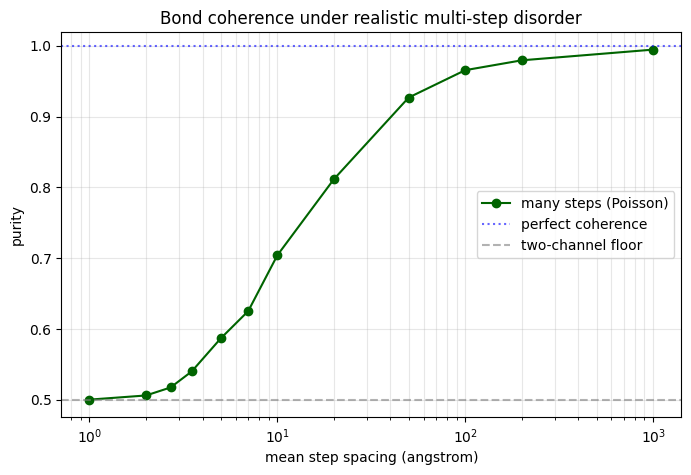

In [3]:

def slater_koster_matrix_sp3s(l, m, n, p):
    Vsp = p["Vsp_sigma"]; Vpp_s = p["Vpp_sigma"]; Vpp_p = p["Vpp_pi"]; Vssp = p["Vssp_sigma"]
    d = np.array([l, m, n])
    M_pp = Vpp_p*np.eye(3) + (Vpp_s - Vpp_p)*np.outer(d, d)
    M = np.zeros((5,5), dtype=complex)
    M[0,0] = p["Vss_sigma"]
    M[0,1:4] = Vsp*d; M[1:4,0] = -Vsp*d
    M[1:4,1:4] = M_pp
    M[4,1:4] = Vssp*d; M[1:4,4] = -Vssp*d
    return M

bond_dirs = np.array([[1,1,1],[1,-1,-1],[-1,1,-1],[-1,-1,1]], dtype=float)
bond_vecs = bond_dirs * (a/4.0)

def bond_amplitudes(z_shifts):
    B = np.zeros(4, dtype=complex)
    for j, dj in enumerate(bond_vecs):
        l, m, n = dj / np.linalg.norm(dj)
        Mj = slater_koster_matrix_sp3s(l, m, n, params_sp3s)
        local = np.vdot(u_plus[:5], Mj @ u_minus[5:])
        z_bond = dj[2] + z_shifts[j]
        phase = np.exp(1j*k0*dj[0]) * np.exp(1j*k0*dj[1]) * np.exp(-1j*2.0*k0*z_bond)
        B[j] = local * phase
    return B

def purity(C):
    return np.real(np.trace(C @ C)) / (np.real(np.trace(C))**2)

def numerical_rank(C, rel_tol=1e-6):
    eigvals = np.sort(np.linalg.eigvalsh(C))[::-1].real
    eigvals = np.clip(eigvals, 0, None)
    return int(np.sum(eigvals > rel_tol * eigvals[0]))

step_height = a / 4.0

def generate_poisson_steps(mean_spacing, total_length, seed=None):
    rng = np.random.default_rng(seed)
    n_expected = int(total_length / mean_spacing) + 10
    gaps = rng.exponential(mean_spacing, size=n_expected)
    positions = np.cumsum(gaps) - total_length/2
    return np.sort(positions[np.abs(positions) < total_length/2])

def height_multistep(x, step_positions):
    return np.sum(step_positions <= x) * step_height

def z_shifts_from_multistep(x0, step_positions):
    shifts = np.zeros(4)
    h0 = height_multistep(x0, step_positions)
    for j, dj in enumerate(bond_vecs):
        shifts[j] = height_multistep(x0 + dj[0], step_positions) - h0
    return shifts

np.random.seed(11)
N_cells = 3000
mean_spacings = np.array([1000, 200, 100, 50, 20, 10, 7, 5, 3.5, 2.7, 2.0, 1.0])

purity_multistep = []
print(f"{'mean spacing (angstrom)':>26s}{'rank':>8s}{'purity':>12s}")
print("-"*46)
for L in mean_spacings:
    total_length = max(500.0, L * 60)
    C_accum = np.zeros((4,4), dtype=complex)
    for trial in range(N_cells):
        step_positions = generate_poisson_steps(L, total_length, seed=trial)
        x0 = np.random.uniform(-total_length/4, total_length/4)
        shifts = z_shifts_from_multistep(x0, step_positions)
        Bmu = bond_amplitudes(shifts)
        C_accum += np.outer(Bmu, Bmu.conj())
    C_accum /= N_cells
    r = numerical_rank(C_accum)
    p = purity(C_accum)
    purity_multistep.append(p)
    print(f"{L:26.2f}{r:8d}{p:12.6f}")

purity_multistep = np.array(purity_multistep)

plt.figure(figsize=(8,5))
plt.semilogx(mean_spacings, purity_multistep, 'o-', color='darkgreen', label='many steps (Poisson)')
plt.axhline(1.0, color='blue', linestyle=':', alpha=0.6, label='perfect coherence')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='two-channel floor')
plt.xlabel('mean step spacing (angstrom)')
plt.ylabel('purity')
plt.title('Bond coherence under realistic multi-step disorder')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.savefig('part8_multistep_purity.png', dpi=120, bbox_inches='tight')
plt.show()


## Chapter 3 — Final Assessment

### What does not survive

The exact recovery of full coherence at small terrace width, the most visually
striking feature reported in Part 2 and confirmed in Part 4, does not appear
under a statistically realistic distribution of many steps. Instead, the
coherence measure decreases smoothly and monotonically as the steps become
denser, with no recovery at any point. The earlier analytic proof of exact
recovery remains mathematically correct for the idealized single-step
configuration it was derived for; what this chapter shows is that this
idealized configuration is not representative of a realistically disordered
interface, and the recovery should not be described as a general prediction of
this model.

### What does survive

The asymptotic value the coherence measure approaches under heavy disorder is
one half in both the single-step and the many-step models, and this number is
not a coincidence: it follows directly from the same geometric fact used
throughout this project, that the four tetrahedral bonds split into exactly two
families according to the sign of their lateral direction, regardless of how
many steps are present or how they are arranged. This deeper structural
statement, unlike the recovery phenomenon built on top of it, does appear to be
robust.

### Why this correction matters

Reporting a striking result and later finding that it does not survive a more
realistic test is a normal and expected part of research, and is recorded here
for the same reason every other correction in this project has been recorded
openly: so that the notebooks remain an accurate account of what is and is not
established, rather than a curated list of only the results that held up.
